# Testing a claim without assuming a distribution

*Question, Intuition, Math, Code, Assumptions, How it breaks*

## 1. Question

"Henry was better than Suárez." That is a claim about two careers, and both of
them left evidence behind. Can the evidence settle it?

Not "is Henry's number bigger", because it is. The question is whether a gap
that size is more than two equally good players would produce by chance.

## 2. Intuition

Suppose the claim is false and the two are equally good. Then which career a
given season belongs to is an accident. Any of those seasons could have been
either player's.

So **shuffle them**. Pool every season from both careers, deal them back out at
the original career lengths, and measure the gap. Then do it ten thousand times.
If the real gap sits comfortably inside the pile of shuffled gaps, chance
explains it. If almost no shuffle reaches it, chance does not.

Notice that no bell curve appeared anywhere in that paragraph. That is the whole
point.

## 3. Math

Observed statistic, for careers $A$ (length $n_A$) and $B$:

$$t_{\text{obs}} = \bar{x}_A - \bar{x}_B$$

Under the null hypothesis of exchangeability, permute the pooled
$n_A + n_B$ values, split at $n_A$, and recompute $t$. Repeating $N$ times:

$$p_{\text{one-sided}} = \frac{1 + \#\{t_b \ge t_{\text{obs}}\}}{N + 1}
\qquad
p_{\text{two-sided}} = \frac{1 + \#\{|t_b| \ge |t_{\text{obs}}|\}}{N + 1}$$

**Why the $+1$ on both sides.** Without it, a claim that no shuffle beats gets
reported as $p = 0$, which asserts impossibility on the strength of ten thousand
tries. The correction puts the floor at $1/(N+1)$, which is the strongest
statement the evidence can actually support.

**Which side, and it matters.** One-sided is right for a claim made *before*
looking. "Henry was better than Suárez" is a prior assertion somebody is willing
to be wrong about. It is **not** right when the direction comes from the data.
Scanning a table sorted by score means the higher scorer is always named first,
so the direction got chosen after seeing the answer, and a one-sided test picked
that way is anti-conservative by roughly a factor of two. On the top eight of
this ranking that is the difference between reporting 5 significant pairs and 3.

**Why not a t-test.** A t-test assumes the sampling distribution of the
difference is normal. A career is five to nineteen numbers, and the underlying
score distribution is visibly skewed. The permutation test assumes only that the
labels are arbitrary under the null, which is a far weaker claim and one that is
actually plausible here.

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")

In [2]:
from gambeta import doubt


def career(name):
    return seasons[seasons["player"] == name]["season_score"].to_numpy()


a, b = "Thierry Henry", "Luis Suárez"
diff, p = doubt.permutation_test(career(a), career(b), n=10_000)
print(f"{a}: {len(career(a))} seasons, mean {career(a).mean():.3f}")
print(f"{b}: {len(career(b))} seasons, mean {career(b).mean():.3f}")
print(f"\nobserved gap {diff:+.3f}, p = {p:.4f}")

Thierry Henry: 10 seasons, mean 1.831
Luis Suárez: 16 seasons, mean 1.455

observed gap +0.376, p = 0.1262


Here is the null distribution, drawn. The observed gap is the vertical line, and
the p-value is the share of the histogram sitting to its right.

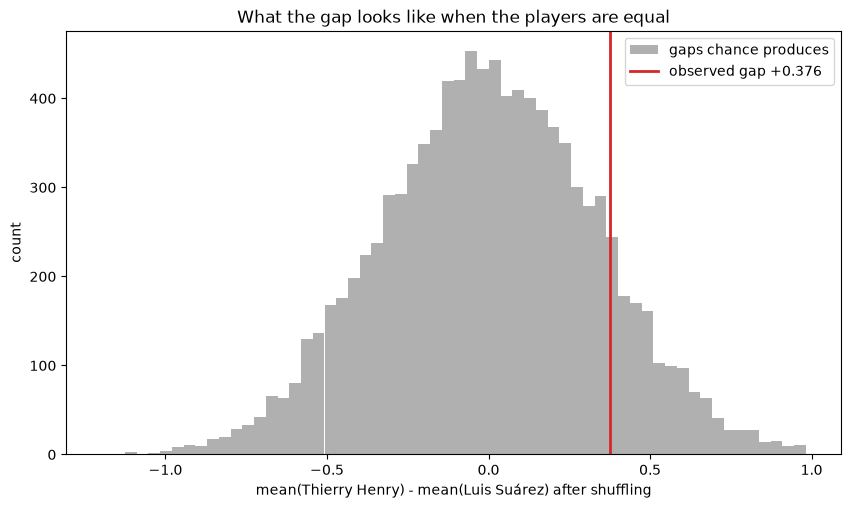

In [3]:
left, right = career(a), career(b)
pooled = np.concatenate([left, right])
rng = np.random.default_rng(20260810)
shuffles = rng.permuted(np.tile(pooled, (10_000, 1)), axis=1)
gaps = shuffles[:, : left.size].mean(axis=1) - shuffles[:, left.size :].mean(axis=1)

fig, ax = plt.subplots()
ax.hist(gaps, bins=60, color="#B0B0B0", edgecolor="none", label="gaps chance produces")
ax.axvline(diff, color="#D62728", linewidth=2, label=f"observed gap {diff:+.3f}")
ax.set_xlabel(f"mean({a}) - mean({b}) after shuffling")
ax.set_ylabel("count")
ax.set_title("What the gap looks like when the players are equal")
ax.legend()
plt.show()

## Every pair in the top eight

One test is an anecdote. Running the whole table is the obvious next step, and
it is where the direction stops being mine to choose: sorted by score, the first
name is always the higher scorer. So this scan is **two-sided**. It tests
"these two differ", which is the only claim the data was ever allowed to
suggest.

I show both columns, because the gap between them is the lesson.

In [4]:
top = ranking[ranking["qualified"]].head(8)["player"].tolist()
rows = []
for i, x in enumerate(top):
    for y in top[i + 1 :]:
        d, one = doubt.permutation_test(career(x), career(y), n=10_000)
        _, two = doubt.permutation_test(career(x), career(y), n=10_000, two_sided=True)
        rows.append({"pair": f"{x} vs {y}", "gap": round(d, 3), "one-sided": one, "two-sided": two})

table = pd.DataFrame(rows).sort_values("two-sided")
print(
    f"of {len(table)} pairs: {(table['one-sided'] < 0.05).sum()} significant one-sided, "
    f"{(table['two-sided'] < 0.05).sum()} two-sided\n"
)
print("Only the two-sided column is legitimate here. The other is what this")
print("table would have claimed if nobody had asked where the direction came from.\n")
table.head(10).round(4)

of 28 pairs: 5 significant one-sided, 2 two-sided

Only the two-sided column is legitimate here. The other is what this
table would have claimed if nobody had asked where the direction came from.



,pair,gap,one-sided,two-sided
5,Lionel Messi vs Luis Suárez,0.853,0.0036,0.0058
6,Lionel Messi vs Robert Lewandowski,0.553,0.0166,0.0338
16,Kylian Mbappé vs Luis Suárez,0.601,0.0311,0.0642
23,Harry Kane vs Luis Suárez,0.495,0.0394,0.0779
11,Cristiano Ronaldo vs Luis Suárez,0.493,0.0432,0.0844
20,Erling Haaland vs Luis Suárez,0.582,0.0614,0.1259
4,Lionel Messi vs Thierry Henry,0.477,0.0712,0.1362
3,Lionel Messi vs Harry Kane,0.358,0.0912,0.1809
0,Lionel Messi vs Cristiano Ronaldo,0.361,0.0916,0.1815
17,Kylian Mbappé vs Robert Lewandowski,0.301,0.1130,0.2322


## The multiple-comparisons trap

That table just ran 28 tests. At a 5% threshold, roughly **one in twenty tests
comes out significant when nothing at all is going on**. So a handful of
"significant" results in a table this size is exactly what pure noise looks
like.

Let me demonstrate that on data with no signal in it whatsoever.

In [5]:
def false_positives(seed: int) -> int:
    """Pairwise tests on eight players who are identical by construction."""
    rng = np.random.default_rng(seed)
    fake = [rng.normal(0, 1, 12) for _ in range(8)]
    return sum(
        doubt.permutation_test(fake[i], fake[j], n=2_000, two_sided=True)[1] < 0.05
        for i in range(len(fake))
        for j in range(i + 1, len(fake))
    )


counts = [false_positives(s) for s in range(12)]
n_tests = 8 * 7 // 2

print(f"{n_tests} tests per run, on players with no real differences at all")
print(f"false positives across 12 runs: {counts}")
print(f"mean {np.mean(counts):.1f}, expected {0.05 * n_tests:.1f}  -- the rate is right")
print(f"but the spread is not: worst run {max(counts)}, and {counts.count(0)} runs found none")
print("\nThe average behaves, and the individual run does not, because the tests")
print("are not independent: eight players generate 28 pairs, so one player who")
print("happens to look extreme drags several pairs over the line together. You")
print("get a single run, and a single run can hand you six.")
print(f"\nBonferroni threshold for {n_tests} tests: {0.05 / n_tests:.4f}")
print("Applied to the real table above, only the top pair survives.")

28 tests per run, on players with no real differences at all
false positives across 12 runs: [1, 1, 0, 1, 0, 3, 0, 6, 0, 3, 0, 0]
mean 1.2, expected 1.4  -- the rate is right
but the spread is not: worst run 6, and 6 runs found none

The average behaves, and the individual run does not, because the tests
are not independent: eight players generate 28 pairs, so one player who
happens to look extreme drags several pairs over the line together. You
get a single run, and a single run can hand you six.

Bonferroni threshold for 28 tests: 0.0018
Applied to the real table above, only the top pair survives.


## 5. Assumptions

1. **Exchangeability under the null.** If the players were equal, any season
   could have belonged to either one. Careers overlapping different eras strain
   this, because a 2003 season and a 2023 season are not freely swappable, which
   is exactly why the scores get era-normalised first.
2. **Seasons are independent within a career.** Same caveat as the bootstrap.
3. **The statistic captures the claim.** A difference in means says nothing
   about peak, and "better" might well mean peak to you.

## 6. How it breaks

**A p-value is not an effect size, and with enough data it stops being
interesting.** A trivial difference turns "significant" once the sample is large
enough.

In [6]:
rng = np.random.default_rng(3)
TRUE_GAP = 0.10  # a tenth of a standard deviation: nobody would see it on a pitch

for n in (50, 250, 1_000, 5_000):
    x, y = rng.normal(TRUE_GAP, 1, n), rng.normal(0, 1, n)
    _, pv = doubt.permutation_test(x, y, n=2_000)
    flag = "<- significant" if pv < 0.05 else ""
    print(f"n = {n:>5}: true gap {TRUE_GAP}, p = {pv:.4f}  {flag}")

print("\nThe difference never changed. Only the evidence for it did.")

n =    50: true gap 0.1, p = 0.1099  
n =   250: true gap 0.1, p = 0.3223  
n =  1000: true gap 0.1, p = 0.0020  <- significant


n =  5000: true gap 0.1, p = 0.0010  <- significant

The difference never changed. Only the evidence for it did.


**And a large p-value is not proof of equality.** "We cannot separate these two"
and "these two are the same" are different statements. The first is about the
evidence, the second is about the world. This project only ever makes the first
one.